# Drone Detection Dataset - Exploratory Data Analysis

## Dataset Description

This study uses the **Anti-UAV300 dataset** introduced by Jian et al. (2023) [10]. The dataset consists of **318 video sequences** with over **580,000 manually annotated bounding boxes**, collected using RGB and infrared cameras mounted on a rotating turret.

The videos cover both **day and night conditions** and include a wide range of background environments such as **buildings, clouds, and trees**, providing diverse and realistic scenarios.

The dataset is divided into:
- **160 training sequences**
- **67 validation sequences**
- **91 test sequences**

The training and validation sets are derived from **non-overlapping clips of the same videos**, while the test set consists of **entirely separate videos**, making it a more challenging and independent evaluation benchmark.

A key characteristic of the dataset is that the **average target size is fewer than 40 pixels**, indicating a strong presence of **small and tiny UAVs**. This makes small-object detection a central challenge in this study.

In this work, only the **RGB modality** is used. The thermal (infrared) stream is excluded in order to focus on **visible-light detection robustness under foggy conditions**.

Since fog is **synthetically applied** to the original RGB frames, the existing manually annotated bounding boxes remain valid as ground truth across all fog levels, meaning that **no re-annotation is required**.

In [12]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [15]:
dataset_path = r"C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\thesis-1\Anti-UAV-RGBT"

records = []

def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    cap.release()
    return fps, frames, width, height


# Loop over splits (train, val, test)
for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    # Loop over numbered subfolders
    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if file.endswith("visible.mp4"):
                video_path = os.path.join(folder_path, file)
                json_path = video_path.replace("visible.mp4", "visible.json")
                
                if not os.path.exists(json_path):
                    continue

                        # Get video info
                fps, total_frames, w, h = get_video_info(video_path)

                # Load annotations (JSON structure)
                with open(json_path) as f:
                    data = json.load(f)

                # `gt_rect` holds bounding boxes and `exist` is the presence of object
                for frame_id, (bbox, exist) in enumerate(zip(data["gt_rect"], data["exist"])):
                    if exist == 1:  # If the object is present in the frame
                        records.append({
                            "split": split,
                            "folder": folder,
                            "video": file,
                            "video_path": os.path.abspath(video_path),                            
                            "fps": fps,
                            "total_frames": total_frames,
                            "width": w,
                            "height": h,
                            "frame_id": frame_id,
                            "bbox": bbox,  # [x, y, w, h]
                            "category": "default_class" 
                        })

df = pd.DataFrame(records)


## Video duration and FPS distribution

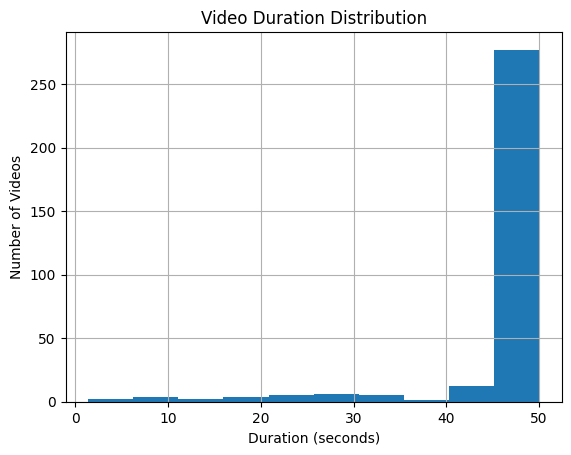

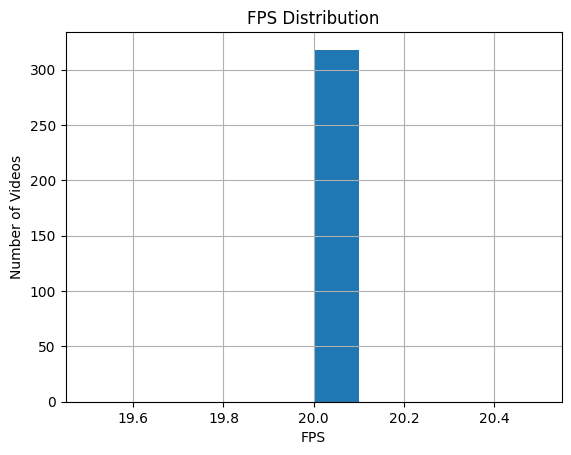

In [ ]:
video_df = df.groupby("video_path").first().reset_index()

# Calculate video duration
video_df["duration"] = video_df["total_frames"] / video_df["fps"]

# Plot video duration distribution
video_df["duration"].hist()
plt.title("Video Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Videos")
plt.show()

# Plot FPS distribution
video_df["fps"].hist()
plt.title("FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Number of Videos")
plt.show()

The video duration distribution reveals a strong concentration of samples in the 45–50 second range, indicating that most videos in the dataset are relatively long and of similar duration. Only a small number of shorter videos are present, resulting in an imbalanced temporal distribution. This suggests that the dataset is dominated by extended sequences, which may introduce bias during training, as longer videos contribute a disproportionately higher number of frames and annotations.

The FPS distribution is completely uniform, with all videos recorded at approximately 20 frames per second. This consistency ensures a standardized temporal resolution across the dataset, which is beneficial for model training, as it eliminates variability in motion representation and simplifies preprocessing requirements.

## Bounding boxes

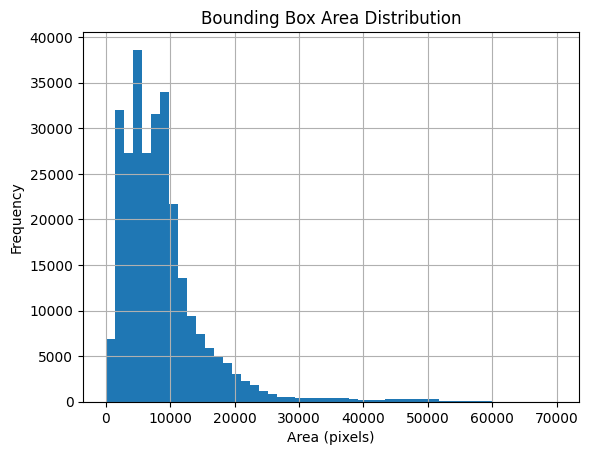

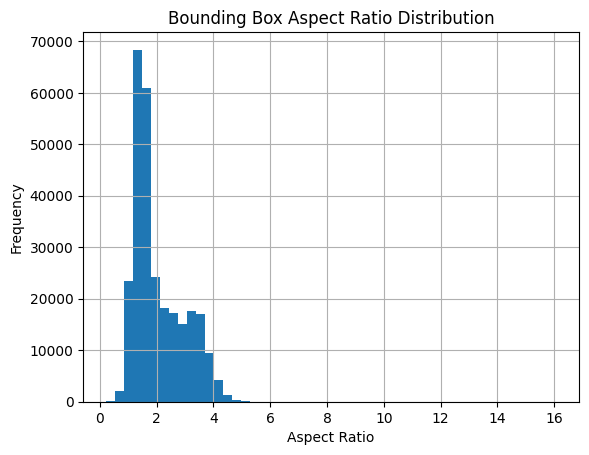

In [ ]:
# Calculate bounding box width, height, area, and aspect ratio
df["bbox_w"] = df["bbox"].apply(lambda x: x[2])
df["bbox_h"] = df["bbox"].apply(lambda x: x[3])
df["area"] = df["bbox_w"] * df["bbox_h"]
df["aspect_ratio"] = df["bbox_w"] / df["bbox_h"]

# Plot Bounding Box Area Distribution
df["area"].hist(bins=50)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Area (pixels)")
plt.ylabel("Frequency")
plt.show()

# Plot Aspect Ratio Distribution
df["aspect_ratio"].hist(bins=50)
plt.title("Bounding Box Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.show()

The bounding box area distribution is highly right-skewed, with most objects occupying relatively small regions of the image. Most bounding boxes fall within the 2,000-to-10,000-pixel range, while larger objects are significantly less frequent. This indicates that the dataset is dominated by small objects, which is characteristic of drone detection tasks. However, this also introduces additional challenges, as small object detection is inherently more difficult due to limited visual detail and higher sensitivity to noise.

The aspect ratio distribution shows that most bounding boxes fall within a range of 1 to 3, with a clear peak around 1.5–2. This indicates that the detected objects are generally wider than they are tall and exhibit relatively consistent geometric proportions. The limited variability in aspect ratios suggests that the dataset contains structurally similar objects, which is advantageous for model training, as it simplifies the learning of object shapes and improves detection stability.

## Bounding box size categories

In [ ]:
# Size thresholds (area in px²) — adjust to match your thesis definition
THRESHOLDS = {"tiny": 1024, "small": 4096, "medium": 16384}  # large = above medium

def size_category(area):
    if area < THRESHOLDS["tiny"]:
        return "Tiny"
    elif area < THRESHOLDS["small"]:
        return "Small"
    elif area < THRESHOLDS["medium"]:
        return "Medium"
    return "Large"

df["size_cat"] = df["area"].apply(size_category)
cat_order = ["Tiny", "Small", "Medium", "Large"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: overall distribution as histogram with category boundaries ---
ax = axes[0]
df["area"].hist(bins=80, ax=ax, color="steelblue", edgecolor="none")
for label, thresh in THRESHOLDS.items():
    ax.axvline(thresh, color="red", linestyle="--", linewidth=1)
    ax.text(thresh + 50, ax.get_ylim()[1] * 0.85, label, color="red", fontsize=9)
ax.set_title("Bounding Box Area Distribution with Size Boundaries")
ax.set_xlabel("Area (px²)")
ax.set_ylabel("Frequency")

# --- Plot 2: instance count per size category per split ---
ax = axes[1]
split_cat = (
    df.groupby(["split", "size_cat"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=cat_order, fill_value=0)
)
split_cat.plot(kind="bar", ax=ax, colormap="tab10", width=0.7)
ax.set_title("Size Category Distribution per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Instances")
ax.legend(title="Size category")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/size_categories.png", dpi=300, bbox_inches="tight")
plt.show()

print(df.groupby(["split", "size_cat"]).size().unstack(fill_value=0).reindex(columns=cat_order, fill_value=0))

## Objects per frame

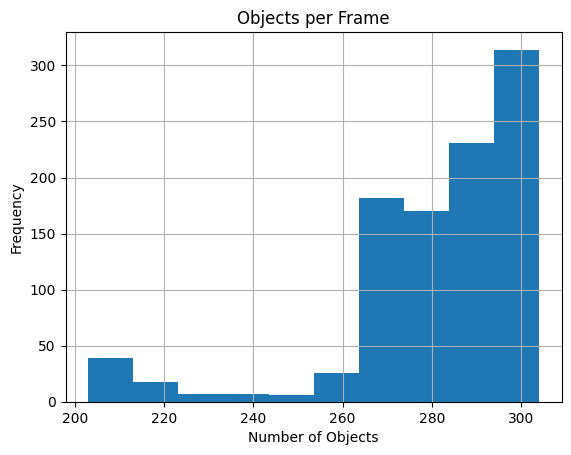

In [ ]:
objects_per_frame = df.groupby(["video", "frame_id"]).size()

# Plot histogram of objects per frame
objects_per_frame.hist()
plt.title("Objects per Frame")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

The distribution of objects per frame reveals that each frame contains a single annotated object, indicating that the dataset follows a single-object tracking paradigm rather than a multi-object detection setting. The values observed in the distribution, ranging approximately between 200 and 300, correspond to the number of annotated frames per video rather than multiple objects per frame. This suggests that videos are consistently annotated across a large number of frames, providing strong temporal continuity and making the dataset well-suited for sequential learning tasks.
This characteristic highlights that the dataset is structured around continuous object tracking, where a single target is followed across time. Such a setup differs from traditional object detection datasets and may influence model selection and evaluation strategies.


## Sequence length distribution

In [ ]:
# Annotated frames per sequence (folder = one video sequence)
seq_len = df.groupby(["split", "folder"])["frame_id"].count().reset_index()
seq_len.columns = ["split", "folder", "annotated_frames"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, split in zip(axes, ["train", "val", "test"]):
    data = seq_len[seq_len["split"] == split]["annotated_frames"]
    ax.hist(data, bins=30, color="steelblue", edgecolor="none")
    ax.set_title(f"{split.capitalize()}  (n={len(data)} sequences)")
    ax.set_xlabel("Annotated frames per sequence")
    ax.set_ylabel("Number of sequences")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.2,
               label=f"Median: {data.median():.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Sequence Length Distribution (annotated frames per video)", y=1.02)
plt.tight_layout()
plt.savefig("figures/sequence_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

## Bounding box location heatmap

In [ ]:
# Normalised bbox centre positions (0–1 relative to frame size)
df["cx_norm"] = (df["bbox"].apply(lambda b: b[0]) + df["bbox_w"] / 2) / df["width"]
df["cy_norm"] = (df["bbox"].apply(lambda b: b[1]) + df["bbox_h"] / 2) / df["height"]

BINS = 64  # grid resolution for the heatmap

heatmap, xedges, yedges = np.histogram2d(
    df["cx_norm"], df["cy_norm"],
    bins=BINS, range=[[0, 1], [0, 1]]
)
heatmap = heatmap.T   # transpose so x=horizontal, y=vertical

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    heatmap,
    origin="upper",
    extent=[0, 1, 1, 0],
    aspect="auto",
    cmap="hot",
    interpolation="gaussian",
)
plt.colorbar(im, ax=ax, label="Instance count")

# Mark frame centre — relevant because fog depth is radial from here
ax.axhline(0.5, color="cyan", linewidth=0.8, linestyle="--", alpha=0.7)
ax.axvline(0.5, color="cyan", linewidth=0.8, linestyle="--", alpha=0.7)
ax.scatter([0.5], [0.5], color="cyan", s=40, zorder=5, label="Frame centre")
ax.legend(fontsize=9)

ax.set_title("UAV Bounding Box Centre Heatmap (all splits)")
ax.set_xlabel("Normalised x")
ax.set_ylabel("Normalised y")

plt.tight_layout()
plt.savefig("figures/bbox_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Visual inspection

In [ ]:
def visualize_sample(video_path, df, n_frames=5):
    import os
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    video_path = os.path.abspath(video_path)
    cap = cv2.VideoCapture(video_path)

    temp = df[df["video_path"] == video_path].copy()

    if temp.empty:
        print("This video_path is not present in df.")
        print("Passed path:", video_path)
        cap.release()
        return

    valid_frames = temp["frame_id"].unique()

    for _ in range(n_frames):
        frame_id = int(np.random.choice(valid_frames))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()

        if not ret:
            print(f"Could not read frame {frame_id}")
            continue

        anns = temp[temp["frame_id"] == frame_id]
        print(f"Frame {frame_id}: {len(anns)} annotations found")

        for _, ann in anns.iterrows():
            x, y, w, h = ann["bbox"]
            cv2.rectangle(frame, (int(x), int(y)),
                          (int(x + w), int(y + h)), (0, 255, 0), 2)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Annotated frame {frame_id}")
        plt.axis("off")
        plt.show()

    cap.release()

Frame 822: 1 annotations found


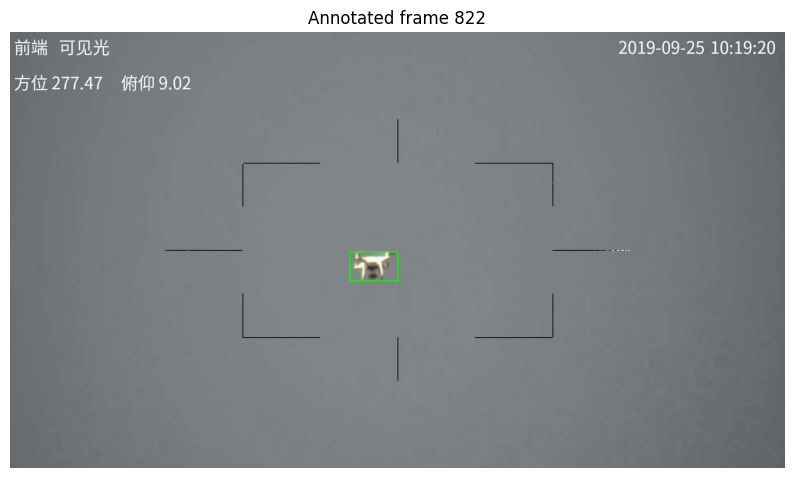

Frame 748: 1 annotations found


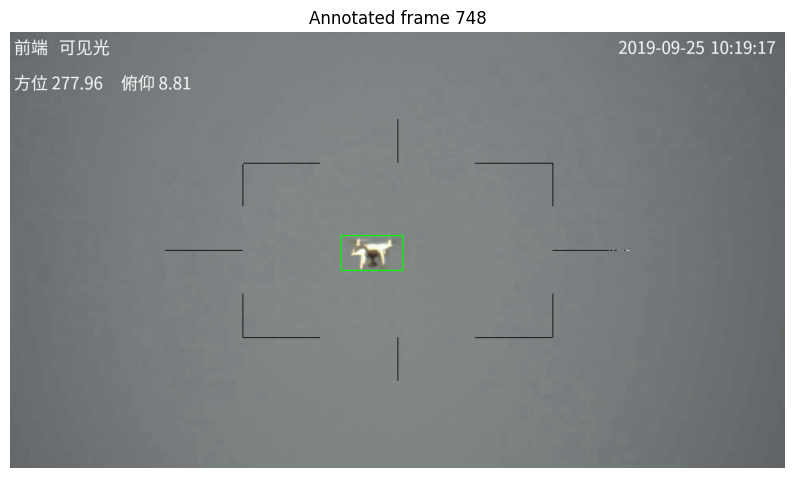

Frame 193: 1 annotations found


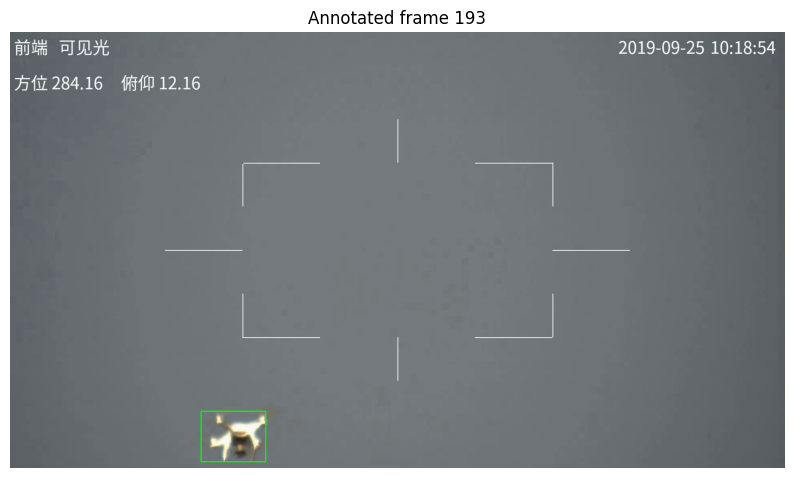

Frame 410: 1 annotations found


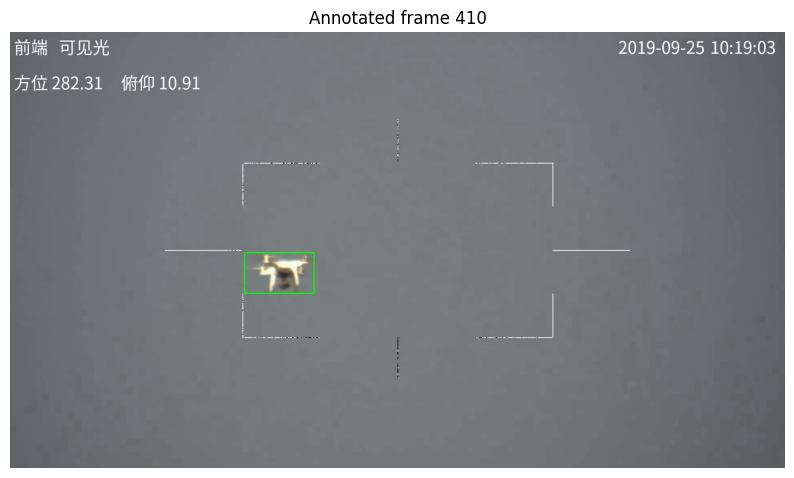

Frame 905: 1 annotations found


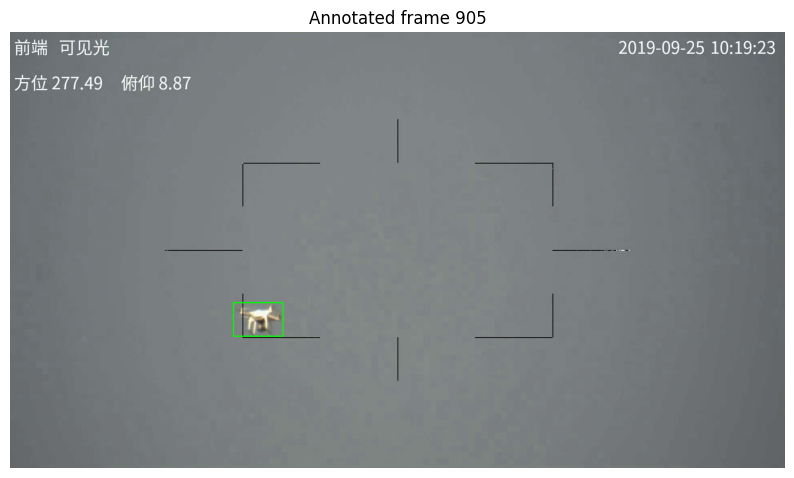

In [ ]:
sample_video = df["video_path"].drop_duplicates().iloc[0]
visualize_sample(sample_video, df)

A visual inspection of randomly selected annotated frames confirms several important characteristics of the dataset. First, each frame contains a single annotated drone, indicating that the dataset follows a single-target structure rather than a multi-object detection setting. Second, the drone occupies only a very small region of the image, reinforcing the conclusion that small object detection is one of the main challenges of the task. Third, the drone appears in different spatial positions across frames, including lateral and upper regions of the image, which suggests that the model must learn to generalize beyond a fixed central location. Finally, the visual conditions are challenging, as the frames exhibit low contrast, blur, and limited background detail, making the drone difficult to distinguish. Overall, these examples confirm that the dataset represents a realistic and demanding drone detection scenario.

## Conclusion

In conclusion, the dataset is consistent in terms of video properties and annotation structure but presents a challenging detection task due to the small size of the drone and difficult visual conditions. While the single-object setup simplifies the problem, the low visibility and limited object scale require models capable of capturing fine spatial details and generalizing across subtle variations in appearance and position.

### Github link

https://github.com/MrRyyper/thesis

In [ ]:
import os

base = "prepared_dataset"
splits = [
    ("clear",    os.path.join(base, "visible",                  "images", "train")),
    ("i02",      os.path.join(base, "visible_fog_i02_beta0.07", "images", "train")),
    ("i05",      os.path.join(base, "visible_fog_i05_beta0.10", "images", "train")),
    ("i09",      os.path.join(base, "visible_fog_i09_beta0.14", "images", "train")),
]

sample_name = sorted(os.listdir(splits[0][1]))[0]
label_path  = os.path.join(base, "visible", "labels", "train",
                            os.path.splitext(sample_name)[0] + ".txt")

def yolo_to_bbox(label_path, img_w, img_h):
    with open(label_path) as f:
        parts = f.readline().split()
    _, cx, cy, bw, bh = map(float, parts)
    x1 = int((cx - bw / 2) * img_w)
    y1 = int((cy - bh / 2) * img_h)
    x2 = int((cx + bw / 2) * img_w)
    y2 = int((cy + bh / 2) * img_h)
    return x1, y1, x2, y2

os.makedirs("figures", exist_ok=True)

for name, folder in splits:
    img = cv2.imread(os.path.join(folder, sample_name))
    img_h, img_w = img.shape[:2]
    x1, y1, x2, y2 = yolo_to_bbox(label_path, img_w, img_h)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 4)

    fig, ax = plt.subplots(1, 1, figsize=(img_w / 300, img_h / 300), dpi=300)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation="lanczos")
    ax.axis("off")
    plt.tight_layout(pad=0)

    out_path = f"figures/fog_{name}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    print(f"Saved → {out_path}")


Saved → figures/fog_clear.png
Saved → figures/fog_i02.png
Saved → figures/fog_i05.png
Saved → figures/fog_i09.png


## Bounding Box

In [17]:
df.head()

,split,folder,video,video_path,fps,total_frames,width,height,frame_id,bbox,category
0,train,20190925_101846_1_1,visible.mp4,C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\th...,20.0,1000.0,1920.0,1080.0,0,"[664, 542, 211, 122]",default_class
1,train,20190925_101846_1_1,visible.mp4,C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\th...,20.0,1000.0,1920.0,1080.0,1,"[663, 542, 211, 121]",default_class
2,train,20190925_101846_1_1,visible.mp4,C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\th...,20.0,1000.0,1920.0,1080.0,2,"[663, 542, 212, 121]",default_class
3,train,20190925_101846_1_1,visible.mp4,C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\th...,20.0,1000.0,1920.0,1080.0,3,"[663, 542, 212, 121]",default_class
4,train,20190925_101846_1_1,visible.mp4,C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\th...,20.0,1000.0,1920.0,1080.0,4,"[662, 542, 213, 120]",default_class


In [22]:
import numpy as np

def get_size_category(w, h):
    scale = np.sqrt(w * h)  # geometric mean, consistent with Jiang et al.
    if scale < 10:
        return "Tiny"
    elif scale < 30:
        return "Small"
    elif scale < 50:
        return "Medium"
    else:
        return "Large"

df["scale"] = np.sqrt(df["bbox_w"] * df["bbox_h"])
df["size_cat"] = df.apply(lambda r: get_size_category(r["bbox_w"], r["bbox_h"]), axis=1)

In [23]:
print(df["scale"].describe())
print(df["scale"].quantile([0.25, 0.5, 0.75, 0.9]))

count    280218.000000
mean         87.306168
std          31.858284
min           0.000000
25%          65.924199
50%          86.116201
75%         102.606043
max         264.586470
Name: scale, dtype: float64
0.25     65.924199
0.50     86.116201
0.75    102.606043
0.90    126.542483
Name: scale, dtype: float64


In [24]:
print(df["split"].value_counts())
print(len(df))

split
train    142192
test      79724
val       58302
Name: count, dtype: int64
280218


In [25]:
print(df["scale"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

0.10     48.631266
0.25     65.924199
0.50     86.116201
0.75    102.606043
0.90    126.542483
Name: scale, dtype: float64


In [26]:
def get_size_category(w, h):
    scale = np.sqrt(w * h)
    if scale < 50:
        return "Small"
    elif scale < 90:
        return "Medium"
    elif scale < 130:
        return "Large"
    else:
        return "Very large"

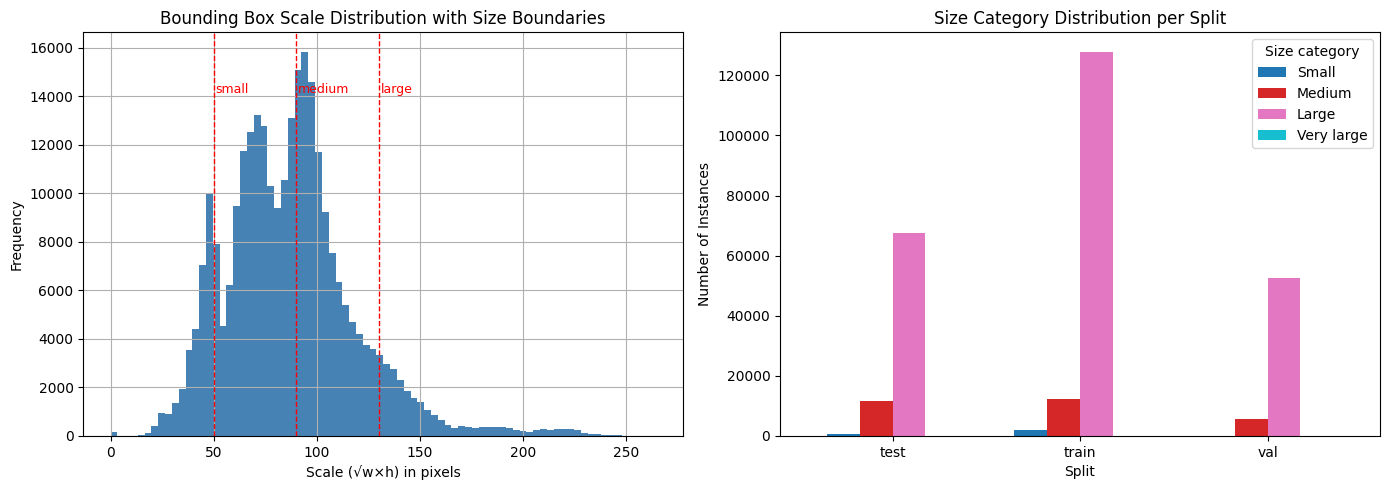

size_cat  Small  Medium   Large  Very large
split                                      
test        494   11657   67546           0
train      1873   12274  127936           0
val         141    5498   52621           0


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: overall distribution as histogram with category boundaries ---
ax = axes[0]
df["scale"].hist(bins=80, ax=ax, color="steelblue", edgecolor="none")
for label, thresh in {"small": 50, "medium": 90, "large": 130}.items():
    ax.axvline(thresh, color="red", linestyle="--", linewidth=1)
    ax.text(thresh + 1, ax.get_ylim()[1] * 0.85, label, color="red", fontsize=9)
ax.set_title("Bounding Box Scale Distribution with Size Boundaries")
ax.set_xlabel("Scale (√w×h) in pixels")
ax.set_ylabel("Frequency")

# --- Plot 2: instance count per size category per split ---
ax = axes[1]
cat_order = ["Small", "Medium", "Large", "Very large"]
split_cat = (
    df.groupby(["split", "size_cat"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=cat_order, fill_value=0)
)
split_cat.plot(kind="bar", ax=ax, colormap="tab10", width=0.7)
ax.set_title("Size Category Distribution per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Instances")
ax.legend(title="Size category")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/size_categories.png", dpi=300, bbox_inches="tight")
plt.show()

print(split_cat)

## Sequence length distribution

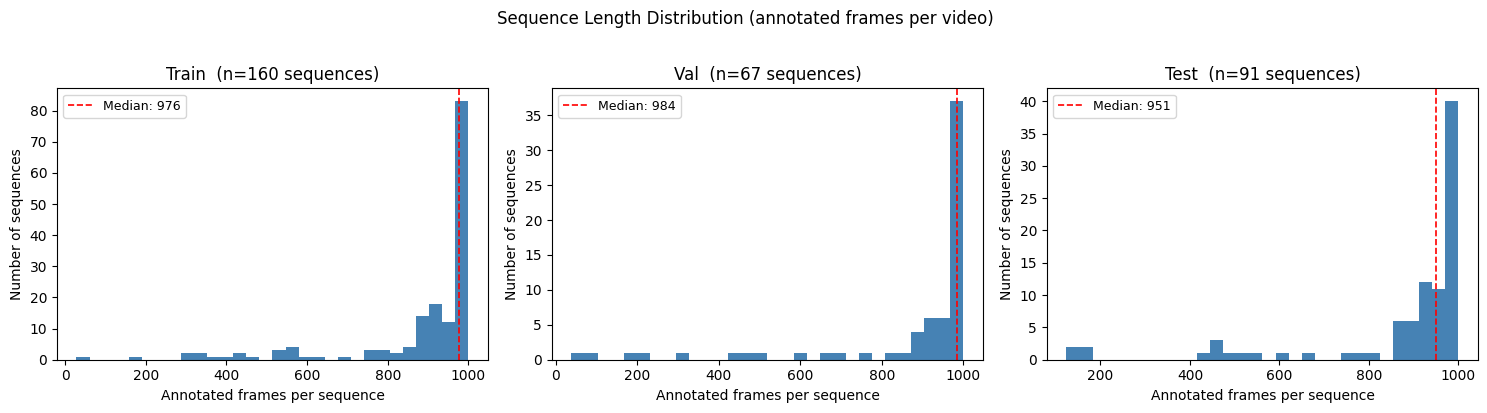

In [28]:
# Annotated frames per sequence (folder = one video sequence)
seq_len = df.groupby(["split", "folder"])["frame_id"].count().reset_index()
seq_len.columns = ["split", "folder", "annotated_frames"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, split in zip(axes, ["train", "val", "test"]):
    data = seq_len[seq_len["split"] == split]["annotated_frames"]
    ax.hist(data, bins=30, color="steelblue", edgecolor="none")
    ax.set_title(f"{split.capitalize()}  (n={len(data)} sequences)")
    ax.set_xlabel("Annotated frames per sequence")
    ax.set_ylabel("Number of sequences")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.2,
               label=f"Median: {data.median():.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Sequence Length Distribution (annotated frames per video)", y=1.02)
plt.tight_layout()
plt.savefig("figures/sequence_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

## Bounding box location heatmap


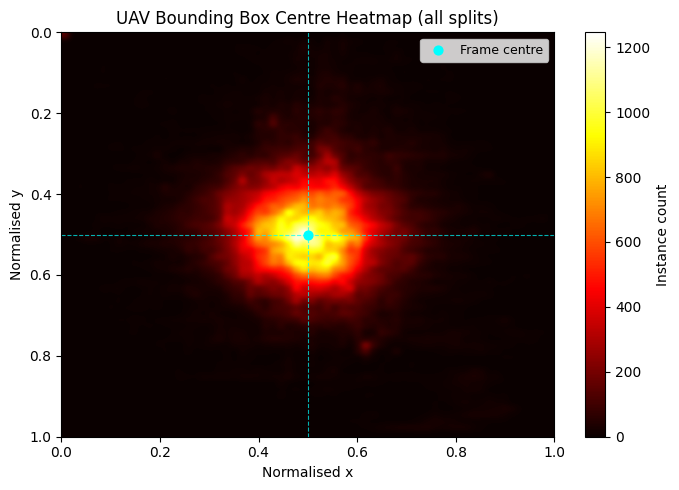

In [29]:
# Normalised bbox centre positions (0–1 relative to frame size)
df["cx_norm"] = (df["bbox"].apply(lambda b: b[0]) + df["bbox_w"] / 2) / df["width"]
df["cy_norm"] = (df["bbox"].apply(lambda b: b[1]) + df["bbox_h"] / 2) / df["height"]

BINS = 64  # grid resolution for the heatmap

heatmap, xedges, yedges = np.histogram2d(
    df["cx_norm"], df["cy_norm"],
    bins=BINS, range=[[0, 1], [0, 1]]
)
heatmap = heatmap.T   # transpose so x=horizontal, y=vertical

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    heatmap,
    origin="upper",
    extent=[0, 1, 1, 0],
    aspect="auto",
    cmap="hot",
    interpolation="gaussian",
)
plt.colorbar(im, ax=ax, label="Instance count")

# Mark frame centre — relevant because fog depth is radial from here
ax.axhline(0.5, color="cyan", linewidth=0.8, linestyle="--", alpha=0.7)
ax.axvline(0.5, color="cyan", linewidth=0.8, linestyle="--", alpha=0.7)
ax.scatter([0.5], [0.5], color="cyan", s=40, zorder=5, label="Frame centre")
ax.legend(fontsize=9)

ax.set_title("UAV Bounding Box Centre Heatmap (all splits)")
ax.set_xlabel("Normalised x")
ax.set_ylabel("Normalised y")

plt.tight_layout()
plt.savefig("figures/bbox_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
import cv2
cap = cv2.VideoCapture(r"C:\Users\Gur Levy\Desktop\UVA\MASTER\THESIS\thesis-1\Anti-UAV-RGBT\train\20190925_130434_1_4\visible.mp4")
ret, frame = cap.read()
print(frame.shape)  # (height, width, channels)
cap.release()

(1080, 1920, 3)


In [37]:
print(df.groupby("split")["scale"].median())

split
test     92.951600
train    79.943730
val      85.457592
Name: scale, dtype: float64
